In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

%cd '/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis/'

/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/playground-uc3/master-thesis


# CUB

In [40]:
def plot_birds_with_masks_paper(
    image_paths: list[Path],
    mask_paths: list[Path],
    image_names: list[str],
    figsize_scale: float = 3.2,
    cmap: str = "magma",
    save: bool = False,
    identifier = ""
):
    """
    Optimiert für Paper:
    - Zeilenbeschriftung 'Images' und 'Masks' am linken Rand.
    - Keine redundanten Titel über den Masken.
    - Engeres Layout für professionelle Optik.
    """
    assert len(image_paths) == len(mask_paths) == len(image_names)
    num_images = len(image_paths)

    # Wir erstellen das Grid
    # Ändere den plt.subplots Aufruf wie folgt:
    fig, axes = plt.subplots(
        2, 
        num_images, 
        figsize=(num_images * figsize_scale, 5.0), # Höhe etwas reduziert
        gridspec_kw={'hspace': -0.15},             # Negativer Wert rückt Zeilen zusammen
        constrained_layout=True
    )

    # Falls nur ein Bild vorhanden ist, axes in 2D-Array umwandeln
    if num_images == 1:
        axes = np.expand_dims(axes, axis=1)

    # --- Zeile 1: Images ---
    for i, (img_path, name) in enumerate(zip(image_paths, image_names)):
        img = np.array(Image.open(img_path).convert("RGB"))
        ax = axes[0, i]
        ax.imshow(img)
        ax.set_title(name, fontsize=12, fontweight='bold')
        ax.axis("off")
        
        # Linke Beschriftung für die erste Zeile
        if i == 0:
            ax.text(-0.15, 0.5, "Images", transform=ax.transAxes, 
                    rotation=90, va='center', ha='right', 
                    fontsize=14, fontweight='bold')

    # --- Zeile 2: Masks ---
    for i, mask_path in enumerate(mask_paths):
        mask = np.array(Image.open(mask_path))
        ax = axes[1, i]
        ax.imshow(mask>0.5, cmap=cmap)
        ax.axis("off")
        
        # Linke Beschriftung für die zweite Zeile
        if i == 0:
            ax.text(-0.15, 0.5, "Object-level\nMasks", transform=ax.transAxes, 
                    rotation=90, va='center', ha='right', 
                    fontsize=14, fontweight='bold')

    if save:
        # dpi=300 ist Standard für hochwertige Drucke
        plt.savefig(f"thesis-figures/others/outputs/{identifier}_examples.pdf", bbox_inches="tight", dpi=300)
    
    plt.show()

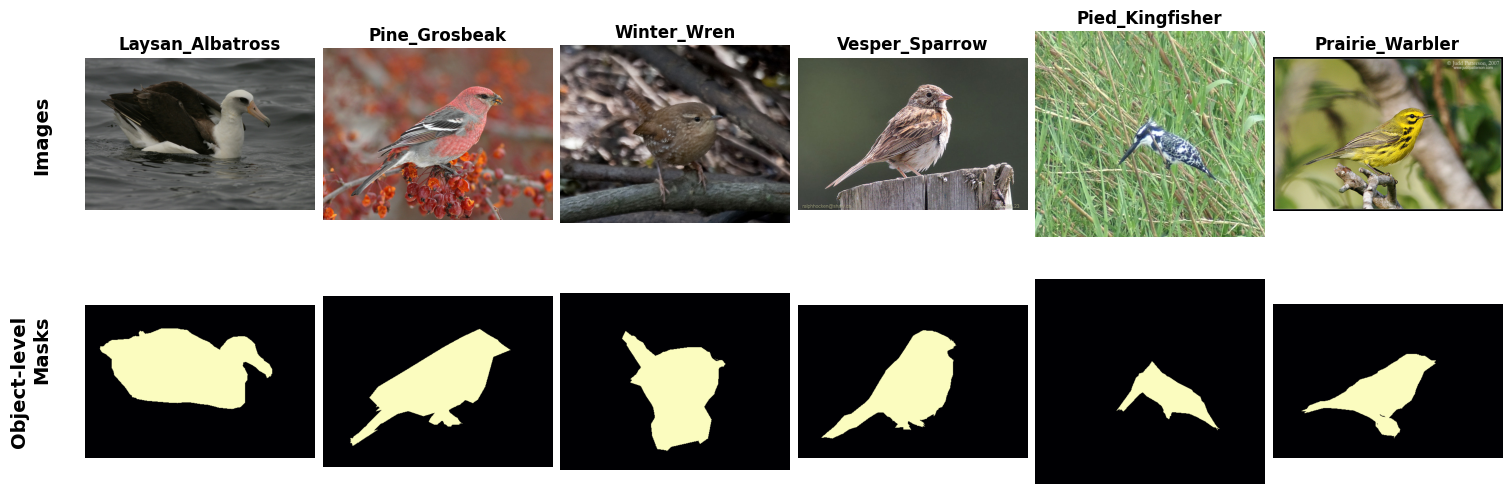

In [41]:
BASE_PATH = Path('/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets/CUB_200_2011/')

image_paths_raw = [
    "002.Laysan_Albatross/Laysan_Albatross_0029_482.jpg",
    "056.Pine_Grosbeak/Pine_Grosbeak_0068_38981.jpg",
    "199.Winter_Wren/Winter_Wren_0097_190139.jpg",
    "131.Vesper_Sparrow/Vesper_Sparrow_0065_125446.jpg",
    "081.Pied_Kingfisher/Pied_Kingfisher_0022_72247.jpg",
    "176.Prairie_Warbler/Prairie_Warbler_0091_172597.jpg"
]

image_paths = [BASE_PATH / "images" / image_path for image_path in image_paths_raw]
segmentation_paths = [BASE_PATH / "segmentations" / image_path.replace('jpg', 'png') for image_path in image_paths_raw]

image_names = [
    "Laysan_Albatross",
    "Pine_Grosbeak",
    "Winter_Wren",
    "Vesper_Sparrow",
    "Pied_Kingfisher",
    "Prairie_Warbler"

]

plot_birds_with_masks_paper(
    image_paths=image_paths,
    mask_paths=segmentation_paths,
    image_names=image_names,
    figsize_scale=2.5,
    save=True,
    identifier='cub'
)

# FunnyBirds

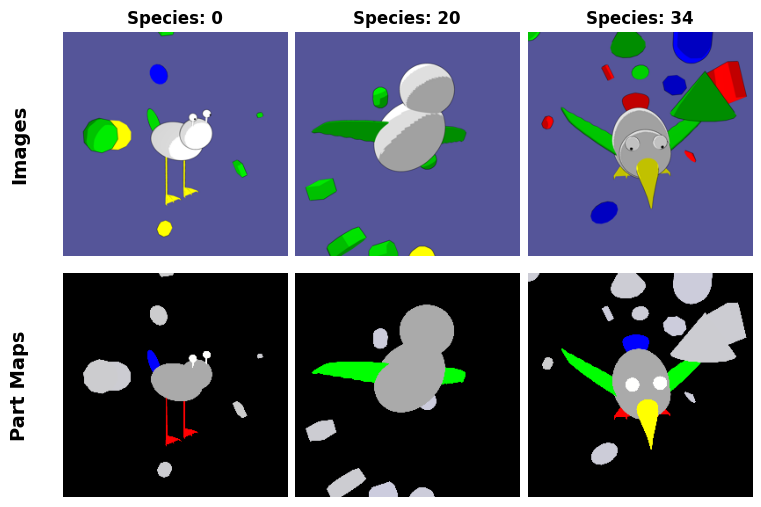

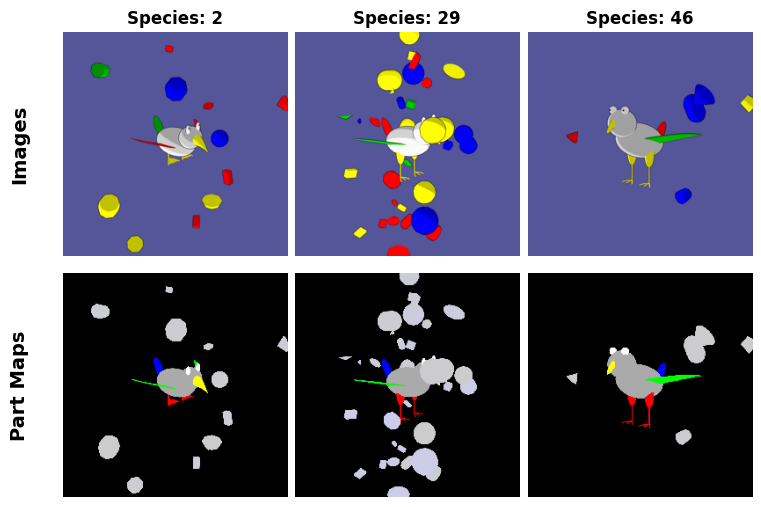

In [35]:
BASE_PATH = Path('/pfs/work9/workspace/scratch/ma_faroesch-master-thesis/datasets/FunnyBirds')

image_paths = [
    "train/0/000334.png",
    "train/20/020335.png",
    "train/34/034447.png",
    "test/2/000020.png",
    "test/29/000291.png",
    "test/46/000469.png"
]

image_paths = [BASE_PATH / image_path for image_path in image_paths]
segmentation_paths = [BASE_PATH / str(image_path).replace('test','test_part_map').replace('train','train_part_map') for image_path in image_paths]

image_names = [
    "Species: 0",
    "Species: 20",
    "Species: 34",
    "Species: 2",
    "Species: 29",
    "Species: 46"

]

plot_birds_with_masks_paper(
    image_paths=image_paths[:3],
    mask_paths=segmentation_paths[0:3],
    image_names=image_names[0:3],
    figsize_scale=2.5,
    save=True,
    identifier='fb_train'
)

plot_birds_with_masks_paper(
    image_paths=image_paths[3:],
    mask_paths=segmentation_paths[3:],
    image_names=image_names[3:],
    figsize_scale=2.5,
    save=True,
    identifier='fb_test'
)